# NB - YOLO + ResNet50 ImageNet Frozen

Notebook này train pipeline **YOLO + ResNet50** giống cách đã làm với YOLO + ViT.

Pipeline:

```text
Dataset gốc 5 lớp
↓
YOLO detect vùng bệnh
↓
Crop vùng bệnh tốt nhất
↓
Nếu không detect / box quá nhỏ → dùng ảnh gốc
↓
Train ResNet50 ImageNet Frozen trên dataset đã crop
↓
Evaluate test set
↓
Xuất learning curve, confusion matrix, classification report, metrics và zip kết quả
```

Classes:

```python
["blight", "common_rust", "gray_spot", "healthy", "not_corn_leaf"]
```

Lưu ý:
- YOLO không có class `not_corn_leaf`, nên ảnh `not_corn_leaf` thường sẽ không detect và được giữ nguyên ảnh gốc.
- YOLO class `health` tương ứng với classification class `healthy`.


In [1]:
# =========================================
# 1. INSTALL
# =========================================

!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires n

In [2]:
# =========================================
# 2. IMPORT
# =========================================

import os
import io
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report

from ultralytics import YOLO

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


2026-06-04 07:43:55.925681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780559036.275245      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780559036.376740      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780559037.293191      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780559037.293246      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780559037.293249      58 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# =========================================
# 3. CONFIG
# =========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Classification dataset 5 class
DATASET_PATH = "/kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2"



YOLO_MODEL_PATH = "/kaggle/input/datasets/kimlonkkk/yolo17/weights/best.pt"
print("Using YOLO:", YOLO_MODEL_PATH)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

MODEL_NAME = "YOLO_ResNet50_ImageNet_Frozen"
OUT_DIR = f"/kaggle/working/{MODEL_NAME}_results"

CROP_DATASET_DIR = "/kaggle/working/yolo_crop_resnet50_dataset"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CROP_DATASET_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

print("Using YOLO:", YOLO_MODEL_PATH)


Using YOLO: /kaggle/input/datasets/kimlonkkk/yolo17/weights/best.pt
Using YOLO: /kaggle/input/datasets/kimlonkkk/yolo17/weights/best.pt


In [4]:
# =========================================
# 4. CHECK PATHS
# =========================================

print("DATASET_PATH exists:", os.path.exists(DATASET_PATH))
print("YOLO_MODEL_PATH exists:", os.path.exists(YOLO_MODEL_PATH))

print("Dataset folders:", os.listdir(DATASET_PATH))


DATASET_PATH exists: True
YOLO_MODEL_PATH exists: True
Dataset folders: ['val', 'test', 'train']


In [5]:
# =========================================
# 5. LOAD YOLO MODEL
# =========================================

yolo_model = YOLO(YOLO_MODEL_PATH)

print("YOLO classes:", yolo_model.names)


YOLO classes: {0: 'blight', 1: 'common_rust', 2: 'gray_spot', 3: 'health'}


In [6]:
# =========================================
# 6. CROP FUNCTION
# =========================================

def crop_with_yolo(image_path, yolo_model, conf_thres=0.25, img_size=224):
    """
    Detect vùng bệnh bằng YOLO và crop bbox confidence cao nhất.

    Nếu không detect được hoặc box quá nhỏ:
    - dùng ảnh gốc để tránh mất ngữ cảnh.

    Trả về:
    - PIL Image RGB đã resize về img_size.
    """

    image = Image.open(image_path).convert("RGB")
    w, h = image.size

    results = yolo_model.predict(
        source=str(image_path),
        conf=conf_thres,
        verbose=False
    )

    boxes = results[0].boxes

    if boxes is not None and len(boxes) > 0:
        confs = boxes.conf.cpu().numpy()
        best_idx = int(np.argmax(confs))

        x1, y1, x2, y2 = boxes.xyxy[best_idx].cpu().numpy()

        box_w = x2 - x1
        box_h = y2 - y1
        box_area = box_w * box_h
        img_area = w * h

        # Nếu box quá nhỏ thì dùng ảnh gốc
        if box_area / img_area < 0.03:
            return image.resize((img_size, img_size))

        # Padding để giữ thêm ngữ cảnh xung quanh vùng bệnh
        pad_x = int(box_w * 0.5)
        pad_y = int(box_h * 0.5)

        x1 = max(0, int(x1) - pad_x)
        y1 = max(0, int(y1) - pad_y)
        x2 = min(w, int(x2) + pad_x)
        y2 = min(h, int(y2) + pad_y)

        if x2 > x1 and y2 > y1:
            image = image.crop((x1, y1, x2, y2))

    image = image.resize((img_size, img_size))

    return image


In [7]:
# =========================================
# 7. CREATE CROPPED DATASET
# =========================================
# Output:
# /kaggle/working/yolo_crop_resnet50_dataset/
#   train/class_name/*.jpg
#   val/class_name/*.jpg
#   test/class_name/*.jpg

splits = ["train", "val", "test"]

image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

crop_stats = {
    "total": 0,
    "saved": 0,
    "errors": 0
}

for split in splits:
    split_dir = Path(DATASET_PATH) / split

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name

        out_class_dir = Path(CROP_DATASET_DIR) / split / class_name
        out_class_dir.mkdir(parents=True, exist_ok=True)

        image_paths = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in image_exts
        ]

        print(f"Processing {split}/{class_name}: {len(image_paths)} images")

        for img_path in image_paths:
            crop_stats["total"] += 1

            try:
                cropped = crop_with_yolo(
                    image_path=img_path,
                    yolo_model=yolo_model,
                    conf_thres=0.25,
                    img_size=IMG_SIZE
                )

                out_path = out_class_dir / img_path.name
                cropped.save(out_path)

                crop_stats["saved"] += 1

            except Exception as e:
                crop_stats["errors"] += 1
                print("Error:", img_path, e)

print("Crop stats:", crop_stats)
print("Cropped dataset saved at:", CROP_DATASET_DIR)


Processing train/common_rust: 1261 images
Processing train/not_corn_leaf: 1690 images
Processing train/blight: 1283 images
Processing train/healthy: 1173 images
Processing train/gray_spot: 1483 images
Processing val/common_rust: 270 images
Processing val/not_corn_leaf: 362 images
Processing val/blight: 275 images
Processing val/healthy: 251 images
Processing val/gray_spot: 317 images
Processing test/common_rust: 271 images
Processing test/not_corn_leaf: 363 images
Processing test/blight: 276 images
Processing test/healthy: 253 images
Processing test/gray_spot: 319 images
Crop stats: {'total': 9847, 'saved': 9847, 'errors': 0}
Cropped dataset saved at: /kaggle/working/yolo_crop_resnet50_dataset


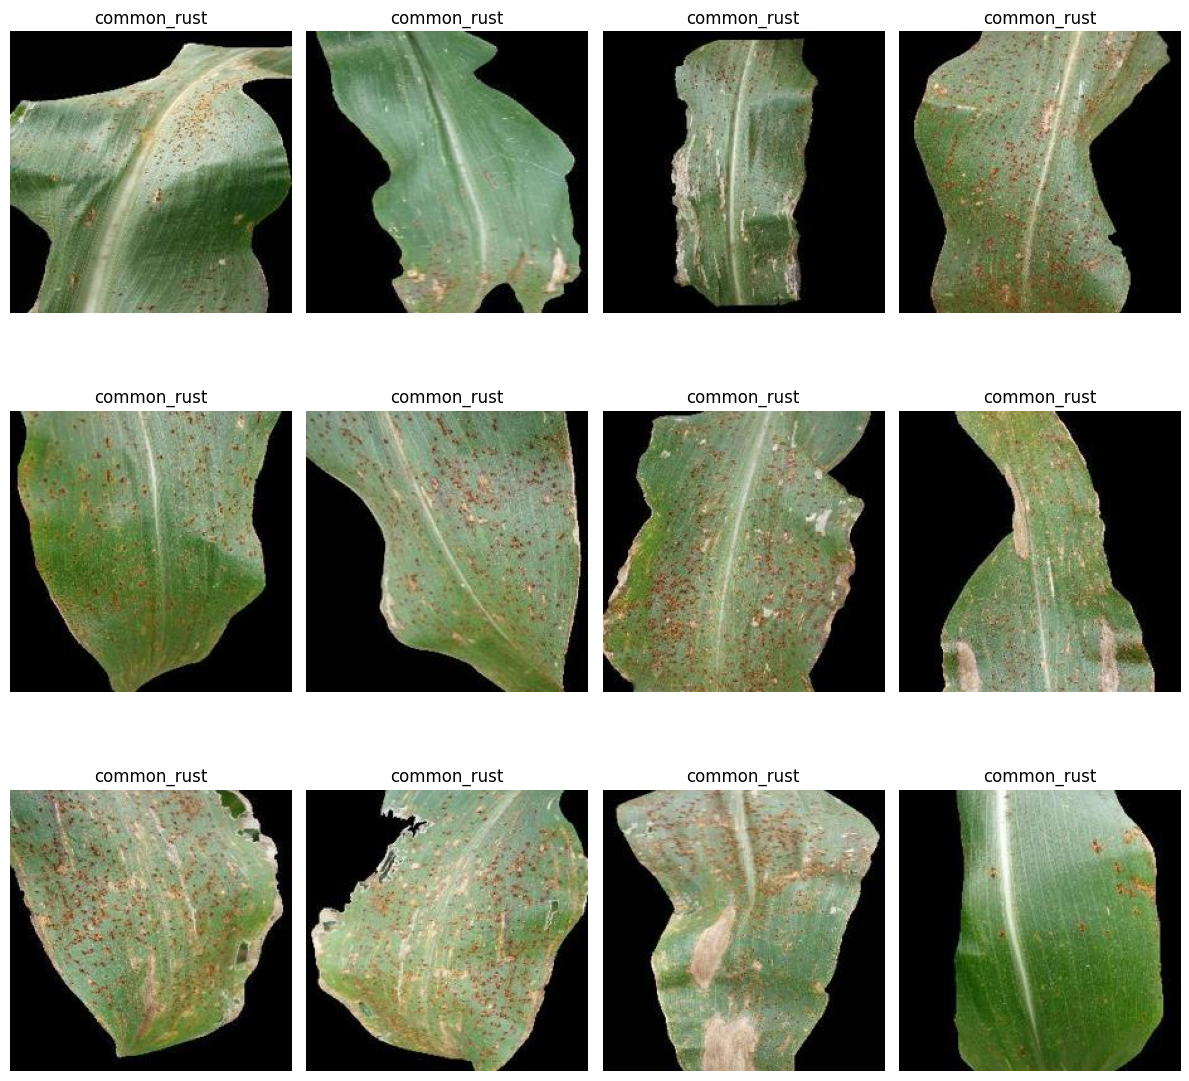

In [8]:
# =========================================
# 8. VISUALIZE SOME CROPPED IMAGES
# =========================================

import glob

sample_images = glob.glob(CROP_DATASET_DIR + "/train/*/*")[:12]

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(Path(img_path).parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
# =========================================
# 9. LOAD CROPPED DATASET
# =========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CROP_DATASET_DIR, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)


Found 6890 files belonging to 5 classes.


I0000 00:00:1780559303.195701      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13677 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780559303.200791      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1475 files belonging to 5 classes.
Found 1482 files belonging to 5 classes.
Classes: ['blight', 'common_rust', 'gray_spot', 'healthy', 'not_corn_leaf']
Num classes: 5


In [10]:
# =========================================
# 10. PREPROCESS + PREFETCH
# =========================================
# ResNet50 ImageNet cần preprocess_input, KHÔNG dùng Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [11]:
# =========================================
# 11. DATA AUGMENTATION NHẸ
# =========================================

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomZoom(0.05),
        layers.RandomTranslation(0.03, 0.03),
    ],
    name="data_augmentation"
)


In [12]:
# =========================================
# 12. BUILD YOLO + RESNET50 IMAGE-NET FROZEN
# =========================================
# ResNet50 sẽ được train lại trên ảnh đã crop bằng YOLO.

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

# Dataset đã preprocess_input trong tf.data pipeline
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(
    inputs,
    outputs,
    name=MODEL_NAME
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "YOLO_ResNet50_ImageNet_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,797 (92.11 MB)

 Trainable params: 558,085 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
# =========================================
# 13. COMPILE
# =========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
# =========================================
# 14. CALLBACKS
# =========================================

checkpoint = ModelCheckpoint(
    filepath=f"{OUT_DIR}/{MODEL_NAME}_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1,
    mode="max"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
    mode="min"
)

callbacks = [
    checkpoint,
    earlystop,
    reduce_lr
]


In [15]:
# =========================================
# 15. TRAIN
# =========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50


I0000 00:00:1780559317.147197     154 cuda_dnn.cc:529] Loaded cuDNN version 91002


216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7837 - loss: 0.5826
Epoch 1: val_accuracy improved from None to 0.93627, saving model to /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/YOLO_ResNet50_ImageNet_Frozen_best.keras

Epoch 1: finished saving model to /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/YOLO_ResNet50_ImageNet_Frozen_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 49s 177ms/step - accuracy: 0.8766 - loss: 0.3270 - val_accuracy: 0.9363 - val_loss: 0.1662 - learning_rate: 0.0010
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9373 - loss: 0.1818
Epoch 2: val_accuracy improved from 0.93627 to 0.96136, saving model to /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/YOLO_ResNet50_ImageNet_Frozen_best.keras

Epoch 2: finished saving model to /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/YOLO_ResNet50_ImageNet_Frozen_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 37s 169ms/step - accuracy: 0.9403 - loss: 0.1654 - val_accuracy: 0.9614

In [16]:
# =========================================
# 16. SAVE HISTORY
# =========================================

history_df = pd.DataFrame(history.history)

history_path = f"{OUT_DIR}/history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
history_df.head()


Saved: /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.876633,0.327034,0.936271,0.166208,0.001
1,0.940348,0.165439,0.961356,0.120688,0.001
2,0.947315,0.137050,0.951864,0.126084,0.001
3,0.957475,0.121811,0.967458,0.103901,0.001
4,0.960522,0.104443,0.963390,0.116275,0.001


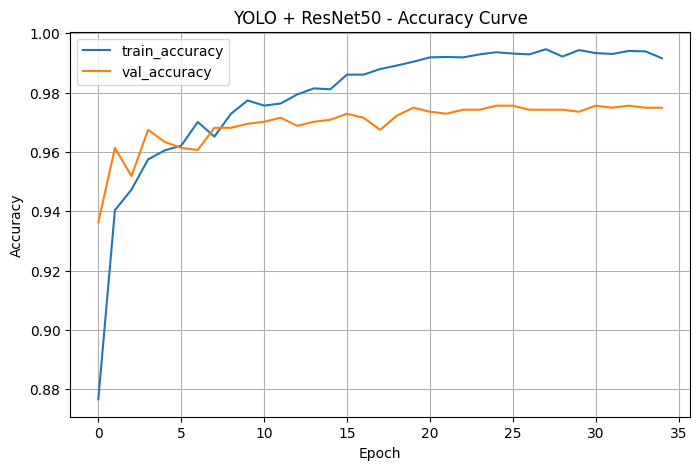

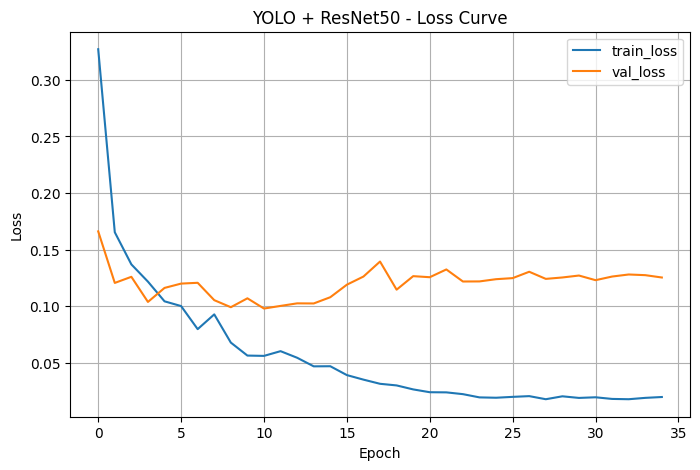

In [17]:
# =========================================
# 17. LEARNING CURVES
# =========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("YOLO + ResNet50 - Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("YOLO + ResNet50 - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# =========================================
# 18. EVALUATE TEST SET
# =========================================

test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.9798 - loss: 0.0770
Test Loss: 0.0770319476723671
Test Accuracy: 0.9797570705413818


In [19]:
# =========================================
# 19. PREDICT TEST SET
# =========================================

y_true = []

for _, y_batch in test_ds:
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)

pred_probs = model.predict(test_ds)
y_pred = np.argmax(pred_probs, axis=1)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)


47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step
y_true: (1482,)
y_pred: (1482,)


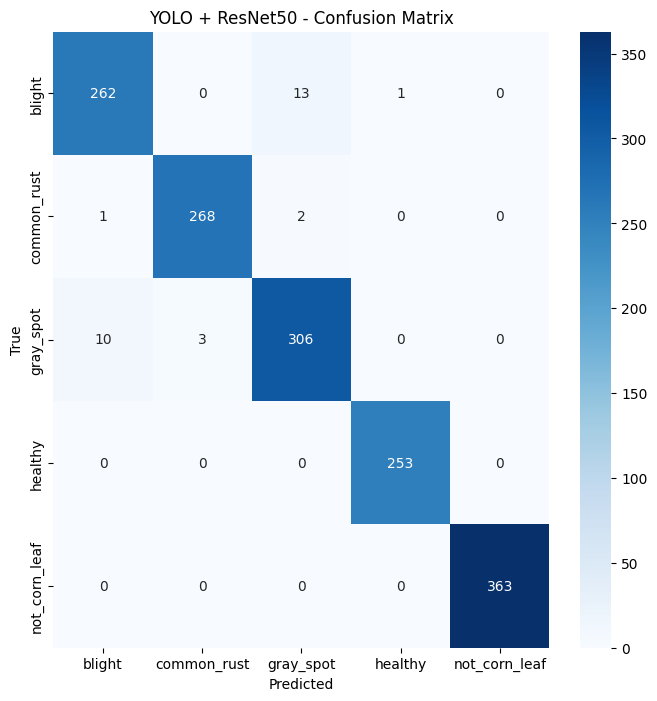

Saved: /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/confusion_matrix.png


In [20]:
# =========================================
# 20. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("YOLO + ResNet50 - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

cm_path = f"{OUT_DIR}/confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)


In [21]:
# =========================================
# 21. CLASSIFICATION REPORT
# =========================================

report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = f"{OUT_DIR}/classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)
report_df


               precision    recall  f1-score   support

       blight       0.96      0.95      0.95       276
  common_rust       0.99      0.99      0.99       271
    gray_spot       0.95      0.96      0.96       319
      healthy       1.00      1.00      1.00       253
not_corn_leaf       1.00      1.00      1.00       363

     accuracy                           0.98      1482
    macro avg       0.98      0.98      0.98      1482
 weighted avg       0.98      0.98      0.98      1482

Saved: /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/classification_report.csv


,precision,recall,f1-score,support
blight,0.959707,0.949275,0.954463,276.000000
common_rust,0.988930,0.988930,0.988930,271.000000
gray_spot,0.953271,0.959248,0.956250,319.000000
healthy,0.996063,1.000000,0.998028,253.000000
not_corn_leaf,1.000000,1.000000,1.000000,363.000000
accuracy,0.979757,0.979757,0.979757,0.979757
macro avg,0.979594,0.979491,0.979534,1482.000000
weighted avg,0.979741,0.979757,0.979741,1482.000000


In [22]:
# =========================================
# 22. SAVE METRICS
# =========================================

metrics = {
    "model_name": MODEL_NAME,
    "pipeline": "YOLO crop + ResNet50 ImageNet Frozen classifier",
    "backbone": "ResNet50",
    "weights": "imagenet",
    "fine_tune": False,
    "yolo_model_path": YOLO_MODEL_PATH,
    "crop_dataset_dir": CROP_DATASET_DIR,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "classes": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS
}

metrics_path = f"{OUT_DIR}/metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved:", metrics_path)


Saved: /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results/metrics.json


In [23]:
# =========================================
# 23. ZIP RESULTS
# =========================================

zip_path = f"/kaggle/working/{MODEL_NAME}_results.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    OUT_DIR
)

print("Saved:", zip_path)


Saved: /kaggle/working/YOLO_ResNet50_ImageNet_Frozen_results.zip


In [24]:
# =========================================
# 24. OPTIONAL - UPLOAD IMAGE FROM COMPUTER AND TEST
# =========================================

from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(
    accept="image/*",
    multiple=False
)

display(uploader)


FileUpload(value=(), accept='image/*', description='Upload')

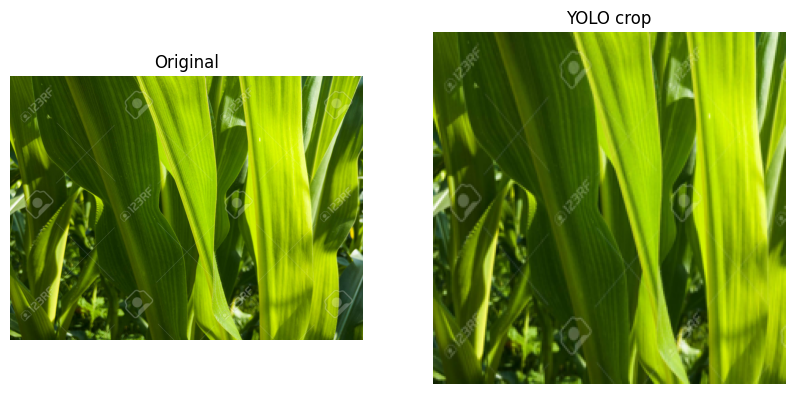

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: healthy
Confidence: 0.8435

All probabilities:
blight         : 0.0862
common_rust    : 0.0567
gray_spot      : 0.0136
healthy        : 0.8435
not_corn_leaf  : 0.0001


In [32]:
# =========================================
# 25. PREDICT UPLOADED IMAGE
# =========================================
# Chạy cell này sau khi chọn ảnh ở cell upload.

if len(uploader.value) == 0:
    raise ValueError("Bạn chưa upload ảnh.")

uploaded = uploader.value[0]

img = Image.open(
    io.BytesIO(uploaded["content"])
).convert("RGB")

temp_path = "/kaggle/working/temp_upload_image.jpg"
img.save(temp_path)

cropped = crop_with_yolo(
    image_path=temp_path,
    yolo_model=yolo_model,
    conf_thres=0.25,
    img_size=IMG_SIZE
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title("YOLO crop")
plt.axis("off")

plt.show()

x = np.array(cropped).astype("float32")
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

pred = model.predict(x)[0]

pred_idx = int(np.argmax(pred))
confidence = float(pred[pred_idx])

print("Prediction:", CLASS_NAMES[pred_idx])
print("Confidence:", f"{confidence:.4f}")

print("\nAll probabilities:")
for cls, prob in zip(CLASS_NAMES, pred):
    print(f"{cls:15s}: {prob:.4f}")
